# Analyse Klebsiella pneumoniae intra-genome variation

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

file ="/home/dca36/rds/rds-floto-bacterial-4k08a2yyQLw/david/processed/pangenome_analysis/gpa_reference_batch_summary_20260402_182612.tsv"

df = pd.read_csv(file, sep="\t")
df.head()


,directory_leaf,modality,resolution,n_samples,n_gpa_samples_raw,n_kpsc_samples,n_unique_sublineages,sublineages_complete,n_unique_clonal_groups,clonal_groups_complete,...,norway_max_mean_jaccard,norway_min_shared_genes,norway_mean_shared_genes,norway_max_shared_genes,norway_min_shared_pct,norway_mean_shared_pct,norway_max_shared_pct,norway_top_genome_ids,norway_top_mean_jaccards,status
0,CG17_all,gpa,0.3,1144,1164,1144,1,False,1,True,...,0.15,4282.78,4241.39,4203.87,93.53,92.63,91.81,"['SAMEA114492509', 'SAMEA111533203', 'SAMEA894...","[0.1214854263776187, 0.1390066275565266, 0.151...",ok
1,CG101_all,gpa,0.3,1561,1561,1561,1,False,1,True,...,0.15,4294.34,4279.68,4269.20,92.34,92.03,91.80,"['SAMEA113605573', 'SAMEA113605418', 'SAMEA894...","[0.14229618854931594, 0.14928306095223115, 0.1...",ok
2,CG16_all,gpa,0.3,1753,1753,1753,1,False,1,True,...,0.10,4405.57,4405.57,4405.57,94.74,94.74,94.74,['SAMEA8948693'],[0.0998932520719497],ok
3,CG231_all,gpa,0.3,1028,1055,1028,1,False,1,True,...,0.13,4295.47,4279.53,4266.72,93.85,93.50,93.22,"['SAMEA8948662', 'SAMEA8948402', 'SAMEA8948510']","[0.11583029393718053, 0.12322880717765303, 0.1...",ok
4,CG14_all,gpa,0.3,2232,2232,2232,1,False,1,True,...,0.18,4298.29,4262.64,4176.31,92.49,91.72,89.86,"['SAMEA113605363', 'SAMEA113605930', 'SAMEA894...","[0.13977314860009818, 0.14086994201844052, 0.1...",ok


In [15]:
# print the list of columns names as a list, one per line
for col in df.columns:
    print(col)


directory_leaf
modality
resolution
n_samples
n_gpa_samples_raw
n_kpsc_samples
n_unique_sublineages
sublineages_complete
n_unique_clonal_groups
clonal_groups_complete
species
strain
samples_in_strain
run_classification
n_leiden_clusters
k_neighbors
min_cluster_size
subclusters_before_merge
genomes_reassigned
subclusters_after_merge
global_medoid_jaccard_mean
own_cluster_medoid_jaccard_mean
gain_jaccard_b_minus_c
gain_similarity
mean_features_per_genome
global_medoid_shared_features_est
own_cluster_medoid_shared_features_est
gain_shared_features_est
global_medoid_shared_features_pct
own_cluster_medoid_shared_features_pct
gain_shared_features_pct_points
mean_genome_size
sd_genome_size
mean_core_genes
sd_core_genes
mean_softcore_genes
sd_softcore_genes
mean_shell_genes
sd_shell_genes
mean_cloud_genes
sd_cloud_genes
global_ref_in_gpa
global_ref_mean_jaccard_to_others
global_ref_mean_shared_genes
global_ref_mean_shared_pct
global_ref_sd_shared_genes
global_ref_divergent_genes_mean
n_refseq_g

In [16]:
# Get unique strain values
strains = df['run_classification'].unique()
print(strains)

# Slice the df to run_classification is in ["sublineage", "sublineage_split", "rare_sublineage  "]
df_sublineage = df[df['run_classification'].isin(["sublineage", "sublineage-split", "rare-lineage"])]

# Get a subtable of strain, n_kpsc_samples, n_unique_sublineages, mean_genome_size, sd_genome_size, mean_core_genes, sd_core_genes, mean_softcore_genes, sd_softcore_genes, mean_shell_genes, sd_shell_genes, mean_cloud_genes, sd_cloud_genes
subtable = df_sublineage[['strain', 'n_kpsc_samples', 'samples_in_strain', 'n_unique_sublineages', 'mean_genome_size', 'sd_genome_size', 'mean_core_genes', 'sd_core_genes', 'mean_softcore_genes', 'sd_softcore_genes', 'mean_shell_genes', 'sd_shell_genes', 'mean_cloud_genes', 'sd_cloud_genes']]


subtable.loc[subtable['strain'] == "Klebsiella pneumoniae", 'samples_in_strain'] = subtable.loc[subtable['strain'] == "Klebsiella pneumoniae", 'n_kpsc_samples']



<StringArray>
[      'clonal-group', 'clonal-group-split',     'non-kp-species',
         'sublineage',   'sublineage-other',   'sublineage-split',
       'rare-lineage']
Length: 7, dtype: str


In [17]:
# If we have two rows with 1 unique sublineage and same strain, then keep the row with the highest n_kpsc_samples or the first if they are the same
subtable = subtable.groupby(['strain', 'n_unique_sublineages']).apply(lambda x: x.loc[x['n_kpsc_samples'].idxmax()])

# Order the rows by n_unique_sublineages ascending, and then by samples_in_strain descending
subtable = subtable.sort_values(by=['n_unique_sublineages', 'samples_in_strain'], ascending=[True, False])

# Ungroup the subtable - keep the index
subtable = subtable.reset_index(drop=False)

# Relabel repeated Klebsiella pneumoniae rows as K.p rare 1..n
kp_mask = subtable['strain'].eq('Klebsiella pneumoniae')
kp_n = int(kp_mask.sum())
subtable.loc[kp_mask, 'strain'] = [f'K.p rare {i}' for i in range(1, kp_n + 1)]

# Print the subtable
display(subtable)




,strain,n_unique_sublineages,n_kpsc_samples,samples_in_strain,mean_genome_size,sd_genome_size,mean_core_genes,sd_core_genes,mean_softcore_genes,sd_softcore_genes,mean_shell_genes,sd_shell_genes,mean_cloud_genes,sd_cloud_genes
0,SL258,1,2500.0,16229.0,4721.60,126.79,3558.73,8.28,367.99,11.81,656.80,115.03,138.08,107.56
1,SL147,1,2548.0,5096.0,4691.16,151.16,3841.20,8.47,186.59,8.43,536.11,169.00,127.26,86.26
2,SL17,1,4630.0,4630.0,4563.32,144.95,3735.34,8.41,192.99,7.73,410.31,114.21,224.67,101.13
3,SL307,1,2225.0,4449.0,4590.19,132.83,3936.84,8.61,131.12,6.47,414.25,84.78,107.98,71.16
4,SL15,1,1824.0,3647.0,4620.74,146.88,3655.59,9.15,369.12,14.57,432.01,84.12,164.02,110.84
5,SL14,1,2521.0,2521.0,4625.80,140.37,3780.55,8.67,212.53,9.98,489.10,173.35,143.61,106.38
6,SL37,1,1871.0,1871.0,4525.13,145.19,3763.10,8.48,162.38,6.04,360.41,57.56,239.24,114.87
7,SL45,1,1803.0,1803.0,4563.35,136.15,3808.11,9.40,210.60,7.98,387.56,130.61,157.09,88.38
8,SL101,1,1610.0,1610.0,4639.75,117.49,3867.76,7.26,153.74,11.80,509.31,114.89,108.94,73.07
9,SL231,1,1049.0,1049.0,4571.54,102.94,3917.26,8.02,205.90,16.33,338.71,79.40,109.67,118.94


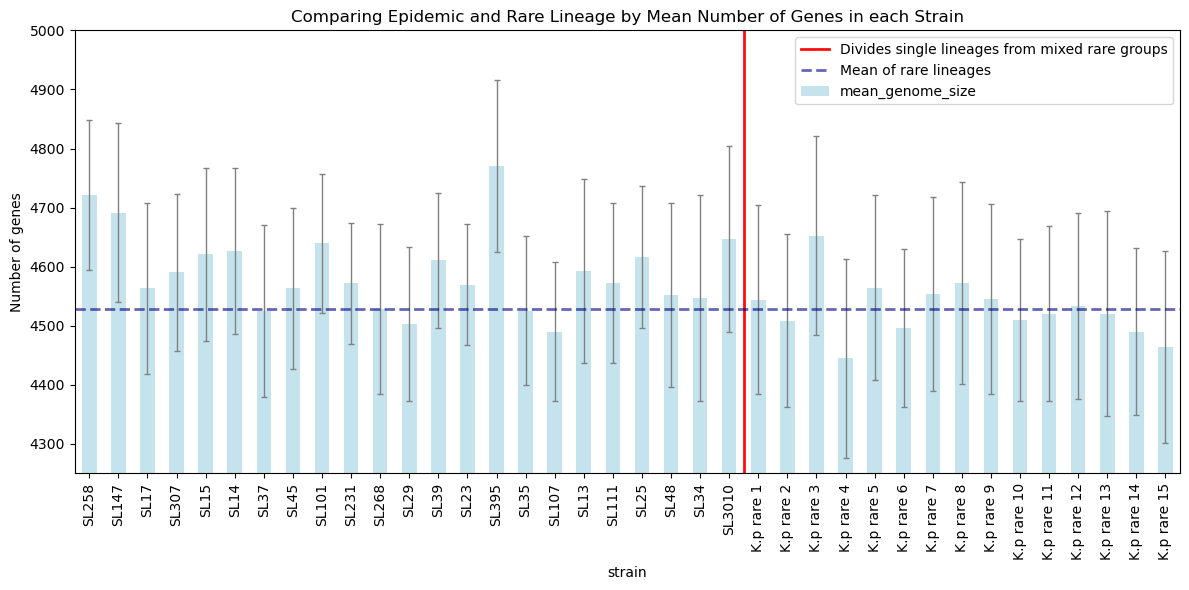

In [34]:
# Plot 1
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 6))

# Comparator mean for strains with >1 unique sublineage (same weighting logic as sublineage_vs_rare_lineage_comparison)
comp = subtable[(subtable['n_unique_sublineages'] > 1) & (subtable['samples_in_strain'] > 1) & (subtable['sd_genome_size'] > 0)].copy()
mean_gt1_unique = float((comp['mean_genome_size'] * comp['samples_in_strain']).sum() / comp['samples_in_strain'].sum()) if not comp.empty else None

# Column plot, with bar height mean_genome_size, and error bar sd_genome_size, use thinner and grey error bars
subtable.plot(kind='bar', x='strain', y='mean_genome_size', yerr='sd_genome_size',
                   legend=False, capsize=2, color='lightblue', alpha=0.7,
                   ecolor='grey', error_kw={'elinewidth':1, 'ecolor':'grey'}, ax=ax)

# Draw separator between n_unique_sublineages == 1 and > 1 groups
n_one = int((subtable['n_unique_sublineages'] == 1).sum())
if 0 < n_one < len(subtable):
    ax.axvline(x=n_one - 0.5, color='red', linewidth=2, alpha=0.95,
               label='Divides single lineages from mixed rare groups')

# Horizontal reference line: mean genes for comparator group (>1 unique sublineage)
if mean_gt1_unique is not None:
    ax.axhline(y=mean_gt1_unique, color='navy', linestyle='--', linewidth=2, alpha=0.6,
               label='Mean of rare lineages')

# Set the y axis label 
ax.set_ylabel("Number of genes")

# Set the whole plot title 
ax.set_title("Comparing Epidemic and Rare Lineage by Mean Number of Genes in each Strain")

# Set the y-axis from 4000 to 5000
ax.set_ylim(4250, 5000)
ax.legend(loc='upper right', frameon=True)
fig.tight_layout()



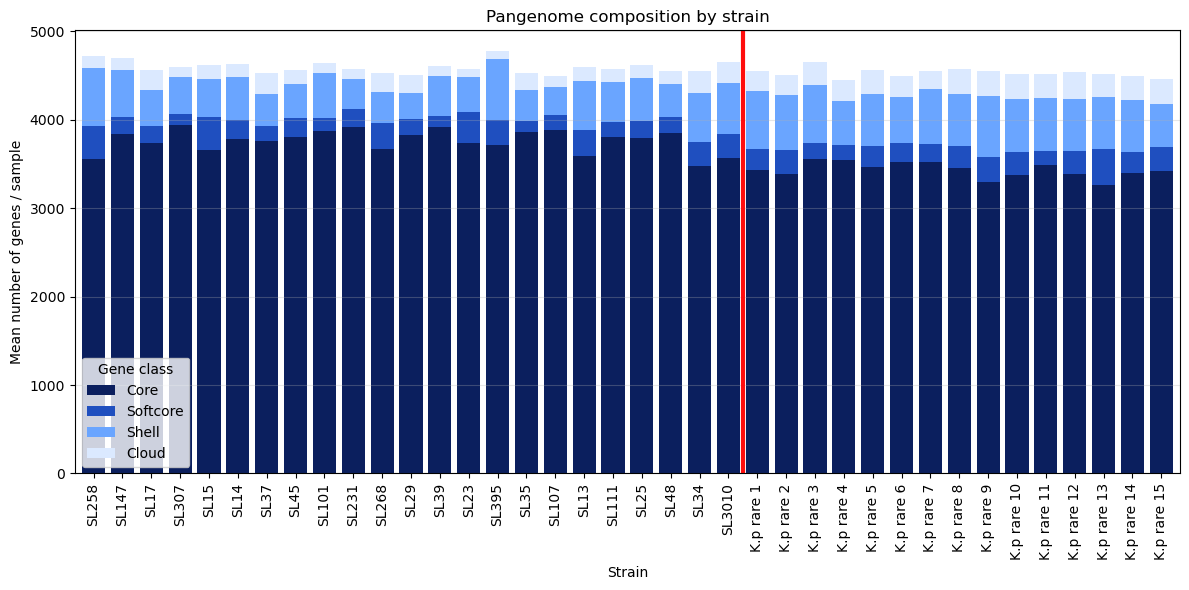

In [28]:
# Plot 2
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

# Stacked cumulative columns for the same strains in subtable
subtable.plot(
    kind='bar',
    x='strain',
    y=['mean_core_genes', 'mean_softcore_genes', 'mean_shell_genes', 'mean_cloud_genes'],
    stacked=True,
    color=['#0b1f5e', '#1f4fbf', '#6aa5ff', '#dbe9ff'],
    width=0.8,
    ax=ax
)

# Draw separator between n_unique_sublineages == 1 and > 1 groups
n_one = int((subtable['n_unique_sublineages'] == 1).sum())
if 0 < n_one < len(subtable):
    ax.axvline(x=n_one - 0.5, color='red', linewidth=3, alpha=0.95)

ax.set_title('Pangenome composition by strain')
ax.set_ylabel('Mean number of genes / sample')
ax.set_xlabel('Strain')
ax.grid(axis='y', alpha=0.3)

# Keep legend tied to stacked bars (exclude separator line)
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles[:4], ['Core', 'Softcore', 'Shell', 'Cloud'], title='Gene class')

fig.tight_layout()


### Requested test: each `n_unique_sublineages == 1` strain vs aggregate of `n_unique_sublineages > 1`

This follows the requested setup exactly:

- Target set: each row where `n_unique_sublineages == 1` (tested one at a time)
- Comparator set: all rows where `n_unique_sublineages > 1` (same comparator for every test)
- Comparator mean: weighted by `samples_in_strain` to represent all comparator samples
- SEs: computed from summary-level variances of means (`sd_genome_size^2 / samples_in_strain`)
- Multiplicity correction: Bonferroni using `m = number of tests = count(n_unique_sublineages == 1)`

Number of tests (m): 23
Comparator rows (n_unique_sublineages > 1): 15
Comparator weighted mean (Genes): 4528.10


,strain,samples_in_strain,target_mean_genome_size,rest_mean_genome_size,estimate_target_minus_rest,se_target_mean,se_diff,z_stat,p_raw,p_bonferroni_m,ci_low,ci_high
0,SL258,16229,4721.60,4528.102839,193.497161,0.995266,1.593330,121.441991,0.000000e+00,0.000000e+00,190.374234,196.620087
1,SL147,5096,4691.16,4528.102839,163.057161,2.117494,2.455998,66.391404,0.000000e+00,0.000000e+00,158.243404,167.870917
2,SL395,851,4770.30,4528.102839,242.197161,4.985276,5.138202,47.136554,0.000000e+00,0.000000e+00,232.126284,252.268038
3,SL101,1610,4639.75,4528.102839,111.647161,2.928114,3.181509,35.092522,8.765663e-270,2.016103e-268,105.411404,117.882918
4,SL15,3647,4620.74,4528.102839,92.637161,2.432175,2.731963,33.908647,4.967565e-252,1.142540e-250,87.282514,97.991808
5,SL14,2521,4625.80,4528.102839,97.697161,2.795683,3.060063,31.926516,1.144618e-223,2.632622e-222,91.699436,103.694885
6,SL307,4449,4590.19,4528.102839,62.087161,1.991430,2.348178,26.440572,4.683535e-154,1.077213e-152,57.484732,66.689589
7,SL39,886,4611.08,4528.102839,82.977161,3.840991,4.037494,20.551647,7.439603e-94,1.711109e-92,75.063671,90.890650
8,SL25,590,4616.15,4528.102839,88.047161,4.930029,5.084618,17.316378,3.539476e-67,8.140796e-66,78.081310,98.013011
9,SL3010,502,4646.94,4528.102839,118.837161,7.002343,7.112029,16.709318,1.121095e-62,2.578518e-61,104.897583,132.776738


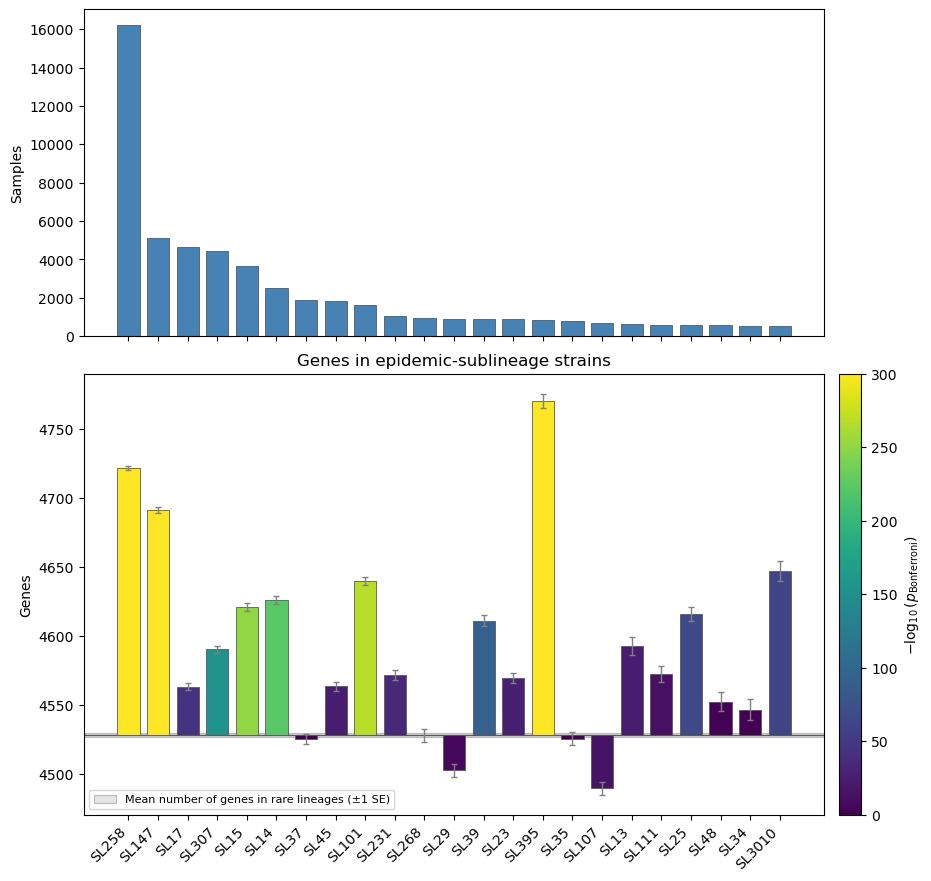

In [21]:
import numpy as np
import pandas as pd
from math import erfc, sqrt
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize

_METRICS = frozenset({
    'genome_size',
    'core_genes',
    'softcore_genes',
    'shell_genes',
    'cloud_genes',
})

_METRIC_YLABEL = {
    'genome_size': 'Genes',
    'core_genes': 'Core genes',
    'softcore_genes': 'Soft-core genes',
    'shell_genes': 'Shell genes',
    'cloud_genes': 'Cloud genes',
}

_METRIC_LEGEND = {
    'genome_size': 'Mean number of genes in rare lineages (±1 SE)',
    'core_genes': 'Mean core genes in rare lineages (±1 SE)',
    'softcore_genes': 'Mean soft-core genes in rare lineages (±1 SE)',
    'shell_genes': 'Mean shell genes in rare lineages (±1 SE)',
    'cloud_genes': 'Mean cloud genes in rare lineages (±1 SE)',
}


def _mean_sd_columns(metric: str) -> tuple[str, str]:
    if metric not in _METRICS:
        raise ValueError(
            f"metric must be one of {sorted(_METRICS)!r}, got {metric!r}"
        )
    return f'mean_{metric}', f'sd_{metric}'


def sublineage_vs_rare_lineage_comparison(
    subtable: pd.DataFrame,
    metric: str = 'genome_size',
    *,
    show_plot: bool = True,
):
    """Compare single-sublineage strains to a sample-weighted rare-lineage pool.

    Uses ``mean_{metric}`` and ``sd_{metric}`` (e.g. ``mean_genome_size`` / ``sd_genome_size``).
    Bonferroni correction is over the number of single-sublineage targets.

    Returns ``(out_df, rest_mean, rest_var)`` or ``(None, None, None)`` if inputs are empty.
    """
    mean_col, sd_col = _mean_sd_columns(metric)
    cols = ['strain', 'n_unique_sublineages', mean_col, sd_col, 'samples_in_strain']
    missing = [c for c in cols if c not in subtable.columns]
    if missing:
        raise KeyError(f'subtable missing columns: {missing}')

    req_df = subtable[cols].copy()
    req_df = req_df.dropna(subset=cols)
    req_df = req_df[(req_df['samples_in_strain'] > 1) & (req_df[sd_col] > 0)].copy()

    req_df['var_mean'] = (req_df[sd_col] ** 2) / req_df['samples_in_strain']

    targets = req_df[req_df['n_unique_sublineages'] == 1].copy()
    rest = req_df[req_df['n_unique_sublineages'] > 1].copy()

    if targets.empty:
        print('No target rows where n_unique_sublineages == 1 after filtering.')
        return None, None, None
    if rest.empty:
        print('No comparator rows where n_unique_sublineages > 1 after filtering.')
        return None, None, None

    rest_weights = rest['samples_in_strain'].to_numpy(dtype=float)
    rest_alpha = rest_weights / rest_weights.sum()

    rest_mean = float(np.sum(rest_alpha * rest[mean_col].to_numpy(dtype=float)))
    rest_var = float(np.sum((rest_alpha ** 2) * rest['var_mean'].to_numpy(dtype=float)))

    target_mean_key = f'target_mean_{metric}'
    rest_mean_key = f'rest_mean_{metric}'

    out = []
    z_crit = 1.96

    for _, row in targets.iterrows():
        target_mean = float(row[mean_col])
        target_var = float(row['var_mean'])

        diff = target_mean - rest_mean
        se_diff = np.sqrt(target_var + rest_var)

        if se_diff <= 0 or np.isnan(se_diff):
            z_stat = np.nan
            p_raw = np.nan
            ci_low = np.nan
            ci_high = np.nan
        else:
            z_stat = diff / se_diff
            p_raw = erfc(abs(z_stat) / sqrt(2.0))  # two-sided p under normal approx.
            ci_low = diff - z_crit * se_diff
            ci_high = diff + z_crit * se_diff

        out.append({
            'strain': row['strain'],
            'n_unique_sublineages': int(row['n_unique_sublineages']),
            'samples_in_strain': int(row['samples_in_strain']),
            target_mean_key: target_mean,
            rest_mean_key: rest_mean,
            'estimate_target_minus_rest': diff,
            'se_target_mean': float(np.sqrt(target_var)),
            'se_diff': se_diff,
            'z_stat': z_stat,
            'p_raw': p_raw,
            'ci_low': ci_low,
            'ci_high': ci_high,
        })

    out_df = pd.DataFrame(out)
    m_tests = len(out_df)
    out_df['p_bonferroni_m'] = np.minimum(out_df['p_raw'] * m_tests, 1.0)
    out_df = out_df.sort_values('p_bonferroni_m').reset_index(drop=True)

    y_short = _METRIC_YLABEL[metric]
    legend_ref = _METRIC_LEGEND[metric]

    print(f'Number of tests (m): {m_tests}')
    print(f'Comparator rows (n_unique_sublineages > 1): {len(rest)}')
    print(f'Comparator weighted mean ({y_short}): {rest_mean:.2f}')

    display_cols = [
        'strain',
        'samples_in_strain',
        target_mean_key,
        rest_mean_key,
        'estimate_target_minus_rest',
        'se_target_mean',
        'se_diff',
        'z_stat',
        'p_raw',
        'p_bonferroni_m',
        'ci_low',
        'ci_high',
    ]
    display(out_df[display_cols])

    if show_plot:
        se_rest = float(np.sqrt(rest_var))
        plot_df = out_df.sort_values('samples_in_strain', ascending=False).reset_index(drop=True)
        x = np.arange(len(plot_df))
        strains = plot_df['strain'].tolist()
        diff = plot_df['estimate_target_minus_rest'].to_numpy()
        p_bonf = np.clip(plot_df['p_bonferroni_m'].to_numpy(dtype=float), 1e-300, 1.0)
        neg_log10_p = -np.log10(p_bonf)
        cmap_p = cm.viridis
        vmax_p = float(np.nanmax(neg_log10_p)) if neg_log10_p.size else 1.0
        if not np.isfinite(vmax_p):
            vmax_p = 1.0
        vmax_p = max(vmax_p, 1e-6)
        norm_p = Normalize(vmin=0.0, vmax=vmax_p)
        bar_colors = cmap_p(norm_p(neg_log10_p))

        fig_h = 5.5 + 3.2
        fig, (ax_top, ax_bottom) = plt.subplots(
            2,
            1,
            sharex=True,
            figsize=(max(9, 0.4 * len(plot_df)), fig_h),
            constrained_layout=True,
            gridspec_kw={'height_ratios': [1, 1.35]},
        )

        ax_top.bar(
            x,
            plot_df['samples_in_strain'],
            width=0.75,
            color='steelblue',
            edgecolor='0.35',
            linewidth=0.6,
        )
        ax_top.set_ylabel('Samples')
        ax_top.tick_params(axis='x', labelbottom=False)

        ax_bottom.axhspan(
            rest_mean - se_rest,
            rest_mean + se_rest,
            facecolor='0.82',
            edgecolor='0.55',
            linewidth=0.8,
            alpha=0.55,
            label=legend_ref,
            zorder=1,
        )
        ax_bottom.axhline(rest_mean, color='0.35', linestyle='-', linewidth=1.0, zorder=2)
        ax_bottom.bar(
            x,
            diff,
            width=0.75,
            bottom=rest_mean,
            yerr=plot_df['se_diff'],
            capsize=2,
            color=bar_colors,
            edgecolor='0.35',
            linewidth=0.6,
            error_kw={'elinewidth': 1, 'ecolor': 'grey'},
            zorder=3,
        )
        ax_bottom.set_ylabel(y_short)
        ax_bottom.set_xticks(x)
        ax_bottom.set_xticklabels(strains, rotation=45, ha='right')
        ax_bottom.legend(loc='lower left', fontsize=8)
        ax_bottom.set_title(f'{y_short} in epidemic-sublineage strains')

        sm_p = cm.ScalarMappable(norm=norm_p, cmap=cmap_p)
        sm_p.set_array([])
        fig.colorbar(sm_p, ax=ax_bottom, pad=0.02, label=r'$-\log_{10}(p_{\mathrm{Bonferroni}})$')

        plt.show()

    return out_df, rest_mean, rest_var


# Default: total genome (gene count)
out_df, rest_mean, rest_var = sublineage_vs_rare_lineage_comparison(subtable)

# Examples:
# out_df, _, _ = sublineage_vs_rare_lineage_comparison(subtable, metric='core_genes')
# out_df, _, _ = sublineage_vs_rare_lineage_comparison(subtable, metric='shell_genes', show_plot=False)


Number of tests (m): 23
Comparator rows (n_unique_sublineages > 1): 15
Comparator weighted mean (Core genes): 3438.35


,strain,samples_in_strain,target_mean_core_genes,rest_mean_core_genes,estimate_target_minus_rest,se_target_mean,se_diff,z_stat,p_raw,p_bonferroni_m,ci_low,ci_high
0,SL258,16229,3558.73,3438.347165,120.382835,0.064996,0.088669,1357.658058,0.0,0.0,120.209043,120.556627
1,SL147,5096,3841.20,3438.347165,402.852835,0.118650,0.133100,3026.683264,0.0,0.0,402.591958,403.113712
2,SL17,4630,3735.34,3438.347165,296.992835,0.123596,0.137528,2159.511801,0.0,0.0,296.723281,297.262389
3,SL307,4449,3936.84,3438.347165,498.492835,0.129084,0.142480,3498.692240,0.0,0.0,498.213575,498.772095
4,SL15,3647,3655.59,3438.347165,217.242835,0.151514,0.163078,1332.142050,0.0,0.0,216.923202,217.562468
5,SL14,2521,3780.55,3438.347165,342.202835,0.172676,0.182907,1870.912622,0.0,0.0,341.844337,342.561333
6,SL37,1871,3763.10,3438.347165,324.752835,0.196046,0.205115,1583.274211,0.0,0.0,324.350810,325.154860
7,SL45,1803,3808.11,3438.347165,369.762835,0.221376,0.229445,1611.552617,0.0,0.0,369.313123,370.212547
8,SL101,1610,3867.76,3438.347165,429.412835,0.180935,0.190724,2251.493315,0.0,0.0,429.039017,429.786653
9,SL231,1049,3917.26,3438.347165,478.912835,0.247621,0.254860,1879.119207,0.0,0.0,478.413309,479.412361


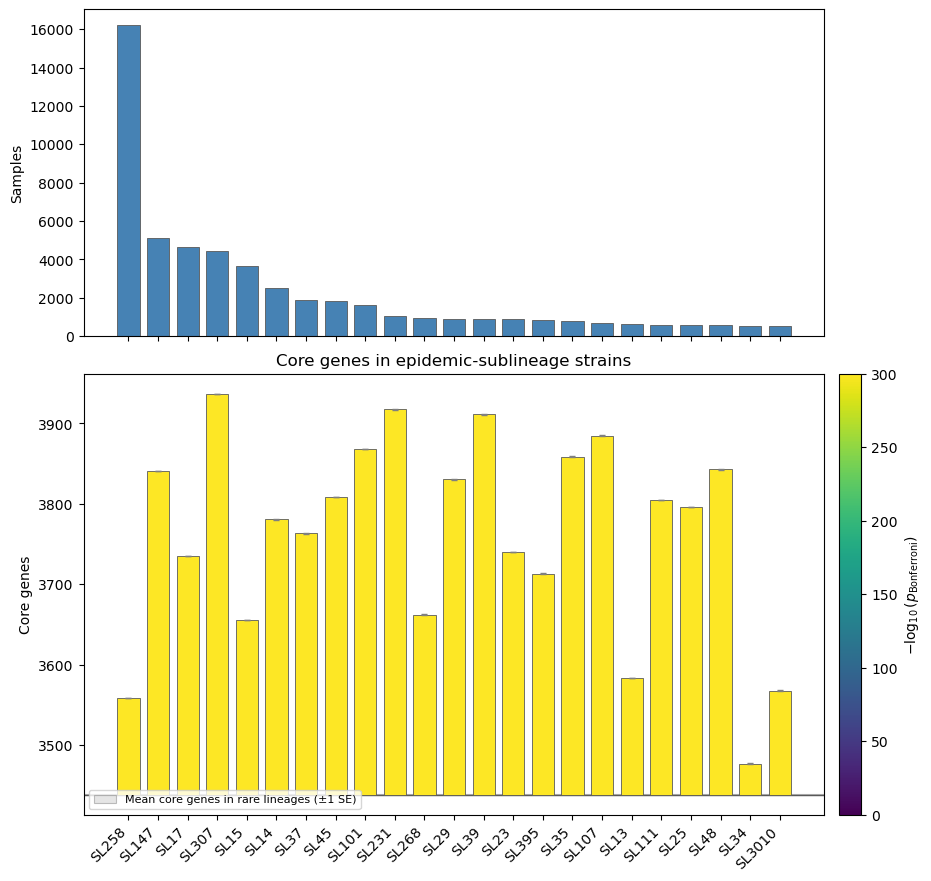

In [22]:
out_df, rest_mean, rest_var = sublineage_vs_rare_lineage_comparison(subtable, metric = "core_genes")

Number of tests (m): 23
Comparator rows (n_unique_sublineages > 1): 15
Comparator weighted mean (Soft-core genes): 239.51


,strain,samples_in_strain,target_mean_softcore_genes,rest_mean_softcore_genes,estimate_target_minus_rest,se_target_mean,se_diff,z_stat,p_raw,p_bonferroni_m,ci_low,ci_high
0,SL258,16229,367.99,239.507209,128.482791,0.092705,0.135919,945.286736,0.0,0.0,128.216389,128.749193
1,SL147,5096,186.59,239.507209,-52.917209,0.118090,0.154354,-342.830878,0.0,0.0,-53.219742,-52.614676
2,SL17,4630,192.99,239.507209,-46.517209,0.113603,0.150948,-308.166276,0.0,0.0,-46.813068,-46.221350
3,SL307,4449,131.12,239.507209,-108.387209,0.097000,0.138884,-780.412931,0.0,0.0,-108.659422,-108.114995
4,SL15,3647,369.12,239.507209,129.612791,0.241264,0.260937,496.721364,0.0,0.0,129.101355,130.124227
5,SL14,2521,212.53,239.507209,-26.977209,0.198767,0.222234,-121.390800,0.0,0.0,-27.412788,-26.541629
6,SL37,1871,162.38,239.507209,-77.127209,0.139637,0.171401,-449.981280,0.0,0.0,-77.463155,-76.791263
7,SL45,1803,210.60,239.507209,-28.907209,0.187934,0.212600,-135.969633,0.0,0.0,-29.323906,-28.490512
8,SL101,1610,153.74,239.507209,-85.767209,0.294082,0.310426,-276.288743,0.0,0.0,-86.375644,-85.158774
9,SL231,1049,205.90,239.507209,-33.607209,0.504195,0.513899,-65.396508,0.0,0.0,-34.614451,-32.599967


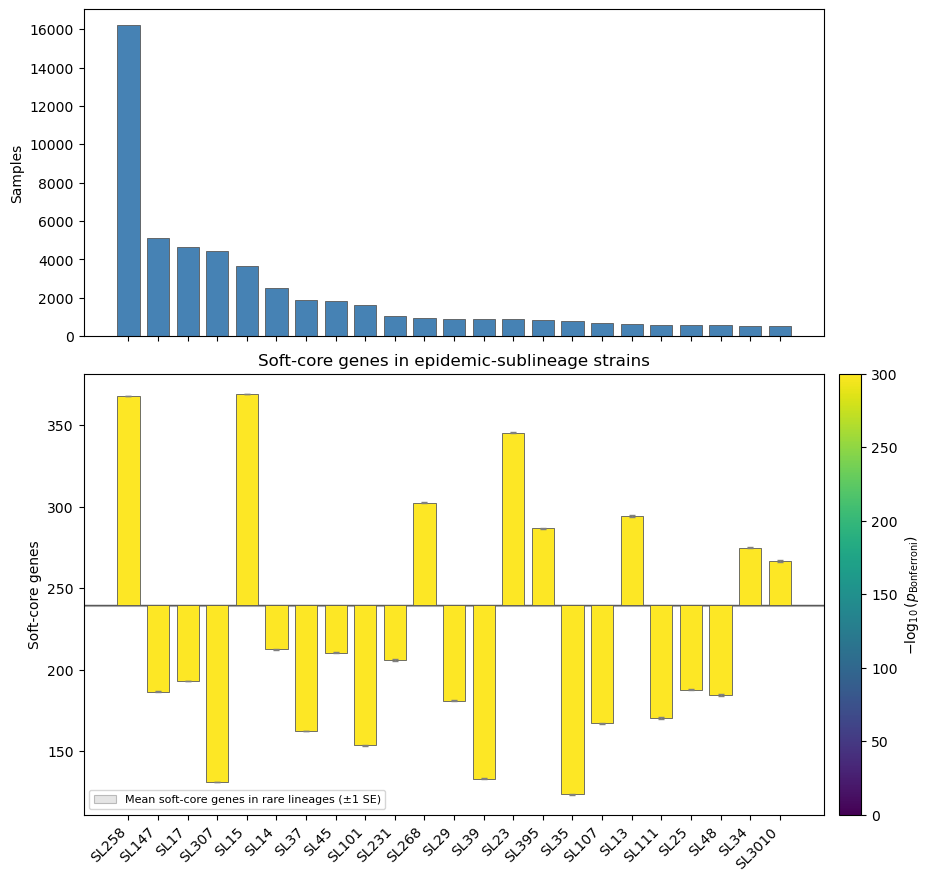

In [23]:
out_df, rest_mean, rest_var = sublineage_vs_rare_lineage_comparison(subtable, metric = "softcore_genes")

Number of tests (m): 23
Comparator rows (n_unique_sublineages > 1): 15
Comparator weighted mean (Shell genes): 590.88


,strain,samples_in_strain,target_mean_shell_genes,rest_mean_shell_genes,estimate_target_minus_rest,se_target_mean,se_diff,z_stat,p_raw,p_bonferroni_m,ci_low,ci_high
0,SL258,16229,656.80,590.884395,65.915605,0.902953,1.254576,52.540160,0.000000e+00,0.000000e+00,63.456637,68.374573
1,SL17,4630,410.31,590.884395,-180.574395,1.678470,1.891004,-95.491259,0.000000e+00,0.000000e+00,-184.280764,-176.868026
2,SL307,4449,414.25,590.884395,-176.634395,1.271049,1.540844,-114.634826,0.000000e+00,0.000000e+00,-179.654450,-173.614341
3,SL15,3647,432.01,590.884395,-158.874395,1.392937,1.642835,-96.707432,0.000000e+00,0.000000e+00,-162.094353,-155.654438
4,SL45,1803,387.56,590.884395,-203.324395,3.075945,3.196885,-63.600786,0.000000e+00,0.000000e+00,-209.590290,-197.058501
5,SL37,1871,360.41,590.884395,-230.474395,1.330711,1.590418,-144.914378,0.000000e+00,0.000000e+00,-233.591614,-227.357176
6,SL268,954,349.83,590.884395,-241.054395,2.862703,2.992274,-80.558924,0.000000e+00,0.000000e+00,-246.919253,-235.189538
7,SL231,1049,338.71,590.884395,-252.174395,2.451505,2.601636,-96.929148,0.000000e+00,0.000000e+00,-257.273602,-247.075188
8,SL35,783,356.70,590.884395,-234.184395,3.266370,3.380504,-69.275000,0.000000e+00,0.000000e+00,-240.810182,-227.558608
9,SL23,863,391.39,590.884395,-199.494395,1.927367,2.115037,-94.321957,0.000000e+00,0.000000e+00,-203.639867,-195.348923


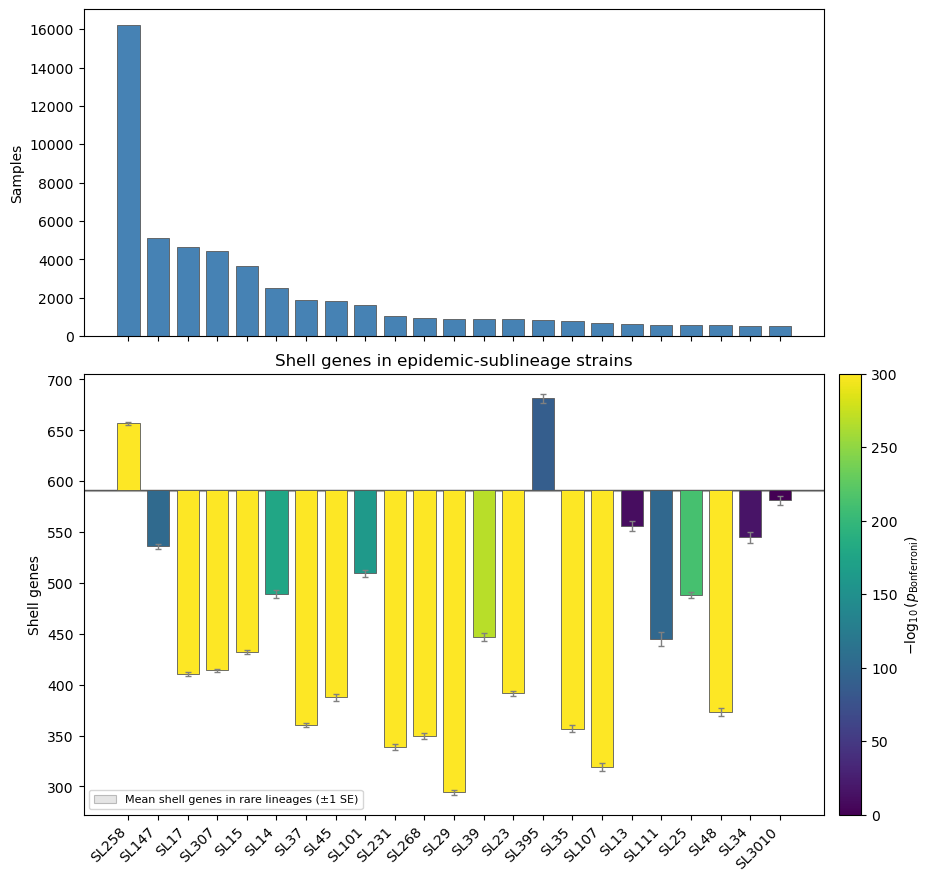

In [24]:
out_df, rest_mean, rest_var = sublineage_vs_rare_lineage_comparison(subtable, metric = "shell_genes")

Number of tests (m): 23
Comparator rows (n_unique_sublineages > 1): 15
Comparator weighted mean (Cloud genes): 259.36


,strain,samples_in_strain,target_mean_cloud_genes,rest_mean_cloud_genes,estimate_target_minus_rest,se_target_mean,se_diff,z_stat,p_raw,p_bonferroni_m,ci_low,ci_high
0,SL258,16229,138.08,259.36355,-121.28355,0.844316,1.297283,-93.490443,0.000000e+00,0.000000e+00,-123.826225,-118.740876
1,SL147,5096,127.26,259.36355,-132.10355,1.208356,1.558909,-84.741035,0.000000e+00,0.000000e+00,-135.159012,-129.048089
2,SL307,4449,107.98,259.36355,-151.38355,1.066853,1.451981,-104.259983,0.000000e+00,0.000000e+00,-154.229434,-148.537667
3,SL15,3647,164.02,259.36355,-95.34355,1.835391,2.082963,-45.773043,0.000000e+00,0.000000e+00,-99.426158,-91.260943
4,SL45,1803,157.09,259.36355,-102.27355,2.081403,2.302675,-44.415108,0.000000e+00,0.000000e+00,-106.786793,-97.760308
5,SL14,2521,143.61,259.36355,-115.75355,2.118720,2.336461,-49.542265,0.000000e+00,0.000000e+00,-120.333013,-111.174088
6,SL231,1049,109.67,259.36355,-149.69355,3.672317,3.802103,-39.371250,0.000000e+00,0.000000e+00,-157.145672,-142.241428
7,SL101,1610,108.94,259.36355,-150.42355,1.821068,2.070353,-72.655984,0.000000e+00,0.000000e+00,-154.481443,-146.365658
8,SL395,851,88.84,259.36355,-170.52355,2.253881,2.459686,-69.327377,0.000000e+00,0.000000e+00,-175.344534,-165.702567
9,SL23,863,92.72,259.36355,-166.64355,2.729699,2.901953,-57.424617,0.000000e+00,0.000000e+00,-172.331379,-160.955722


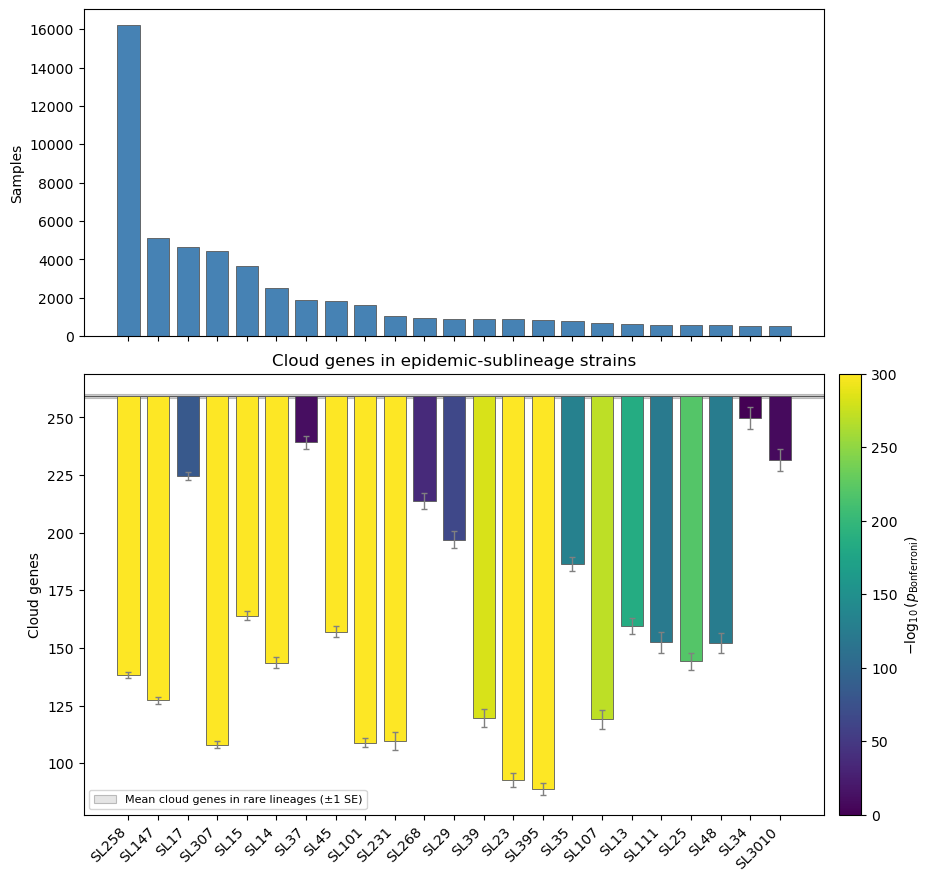

In [25]:
out_df, rest_mean, rest_var = sublineage_vs_rare_lineage_comparison(subtable, metric = "cloud_genes")